<a href="https://colab.research.google.com/github/dante513/Portafolio/blob/main/Copia_de_TelecomX_Informe_Final_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 TelecomX — Análisis de Evasión de Clientes (Churn)
**Proyecto de Análisis de Datos | Telecom Industry**

---

## 🔹 1. Introducción

### Objetivo del Análisis

Este proyecto analiza los datos de clientes de **TelecomX** con el fin de identificar los factores que influyen en la **evasión de clientes (Churn)**: el fenómeno por el cual un cliente decide cancelar el servicio contratado.

### ¿Por qué es importante el Churn?

En la industria de telecomunicaciones, retener a un cliente existente es significativamente menos costoso que adquirir uno nuevo. Comprender qué variables predicen la cancelación permite a la empresa:

- Actuar preventivamente sobre clientes en riesgo
- Diseñar estrategias de fidelización más efectivas
- Optimizar los planes de precios y contratos

### Dataset

El dataset contiene **7.267 registros** de clientes con información demográfica, servicios contratados, tipo de contrato y facturación. Las columnas originales agrupan datos en estructuras anidadas (`customer`, `phone`, `internet`, `account`) que serán expandidas durante la transformación.

### Metodología

El análisis sigue el proceso **ETL + EDA**:
1. **Extracción** de datos desde JSON
2. **Transformación** y limpieza
3. **Análisis Exploratorio** con visualizaciones
4. **Conclusiones** e insights accionables

---
## 📌 Extracción
### 2. Importación de Librerías y Datos

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_json('TelecomX_Data.json')
print(f'Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas')
print('Columnas originales:', df.columns.tolist())
df.head()

Dataset cargado: 7267 filas x 6 columnas
Columnas originales: ['customerID', 'Churn', 'customer', 'phone', 'internet', 'account']


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


---
## 🔧 Transformación
### 3. Limpieza y Tratamiento de Datos

### 3.1 Expansión de columnas con diccionarios anidados

El dataset contiene columnas que almacenan diccionarios: `customer`, `phone`, `internet` y `account`.
La columna `account` además contiene un sub-diccionario `Charges` con los campos `Monthly` y `Total`.
Se expanden todas como columnas independientes.

In [ ]:
# Expandir customer, phone, internet
for col in ['customer', 'phone', 'internet']:
    expanded = df[col].apply(pd.Series)
    df = pd.concat([df, expanded], axis=1)
    df = df.drop(columns=[col])

# Expandir account (contiene Charges anidado)
account_df = df['account'].apply(pd.Series)
charges_df = account_df['Charges'].apply(pd.Series)
charges_df.columns = ['Charges_Monthly', 'Charges_Total']
account_df = account_df.drop(columns=['Charges'])
df = pd.concat([df, account_df, charges_df], axis=1)
df = df.drop(columns=['account'])

print(f'Dataset expandido: {df.shape[0]} filas x {df.shape[1]} columnas')
print('Columnas:', df.columns.tolist())
df.head()

Dataset expandido: 7267 filas x 21 columnas
Columnas: ['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges_Monthly', 'Charges_Total']


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


### 3.2 Revisión de valores nulos y strings vacíos

In [ ]:
nulos = df.isnull().sum()
print('Valores nulos por columna:')
print(nulos[nulos > 0] if nulos.any() else 'Sin valores nulos')

# La columna Churn puede tener strings vacios ''
vacios_churn = (df['Churn'] == '').sum()
print(f'\nStrings vacios en Churn: {vacios_churn}')

df['Churn'] = df['Churn'].replace('', pd.NA)
df = df.dropna(subset=['Churn'])
print(f'Filas tras limpiar Churn vacios: {len(df)}')

Valores nulos por columna:
Sin valores nulos

Strings vacios en Churn: 224
Filas tras limpiar Churn vacios: 7043


### 3.3 Revisión de duplicados

In [ ]:
# Las columnas con dicts ya fueron expandidas: duplicated() funciona sin errores
duplicados = df.duplicated().sum()
print(f'Filas duplicadas encontradas: {duplicados}')

if duplicados > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Duplicados eliminados. Filas restantes: {len(df)}')
else:
    print('No hay duplicados.')

Filas duplicadas encontradas: 0
No hay duplicados.


### 3.4 Corrección de tipos de datos

In [ ]:
# Charges_Total viene como string ('593.3') -> convertir a float
df['Charges_Total'] = pd.to_numeric(df['Charges_Total'], errors='coerce')

# Columna de facturacion diaria
df['Charges_Daily'] = df['Charges_Monthly'] / 30

print('Tipos de datos:')
print(df.dtypes)
print(f'\nDataset listo: {df.shape[0]} registros, {df.shape[1]} columnas')

Tipos de datos:
customerID           object
Churn                object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
Charges_Monthly     float64
Charges_Total       float64
Charges_Daily       float64
dtype: object

Dataset listo: 7043 registros, 22 columnas


### 3.5 Resumen del dataset limpio

In [ ]:
print('Distribucion de Churn:')
print(df['Churn'].value_counts())
print()
df.describe(include='all')

Distribucion de Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64



,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total,Charges_Daily
count,7043,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7032.000000,7043.000000
unique,7043,2,2,NaN,2,2,NaN,2,3,3,...,3,3,3,3,3,2,4,NaN,NaN,NaN
top,9995-HOTOH,No,Male,NaN,No,No,NaN,Yes,No,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,NaN
freq,1,5174,3555,NaN,3641,4933,NaN,6361,3390,3096,...,3095,3473,2810,2785,3875,4171,2365,NaN,NaN,NaN
mean,NaN,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,2283.300441,2.158723
std,NaN,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,2266.771362,1.003002
min,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,18.800000,0.608333
25%,NaN,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,401.450000,1.183333
50%,NaN,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,1397.475000,2.345000
75%,NaN,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,3794.737500,2.995000


---
## 📊 Carga y análisis
### 4. Análisis Exploratorio de Datos (EDA)

### 4.1 Distribución general del Churn

/tmp/ipykernel_290/2846655200.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2', ax=axes[0])


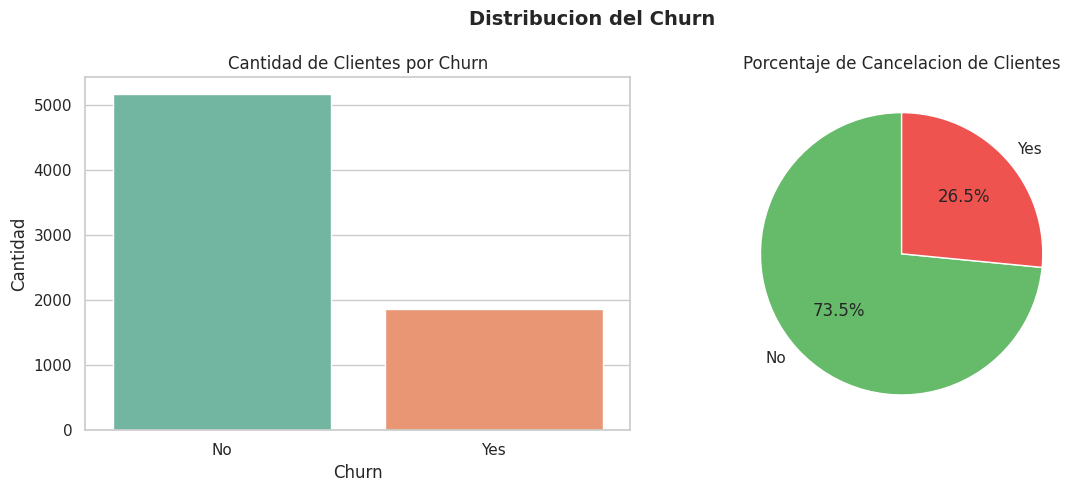

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='Churn', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Cantidad de Clientes por Churn')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Cantidad')

churn_pct = df['Churn'].value_counts(normalize=True) * 100
axes[1].pie(churn_pct, labels=churn_pct.index, autopct='%1.1f%%',
            startangle=90, colors=['#66BB6A', '#EF5350'])
axes[1].set_title('Porcentaje de Cancelacion de Clientes')

plt.suptitle('Distribucion del Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(churn_pct.round(2))

### 4.2 Churn según tipo de contrato

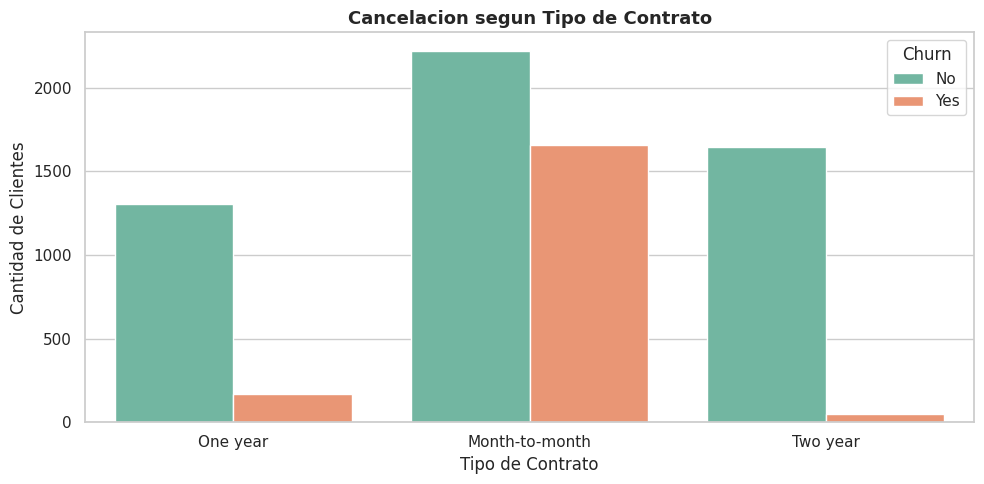

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set2')
plt.title('Cancelacion segun Tipo de Contrato', fontsize=13, fontweight='bold')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Cantidad de Clientes')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

### 4.3 Facturación mensual según Churn

/tmp/ipykernel_290/554357841.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Charges_Monthly', data=df, palette='Set2')


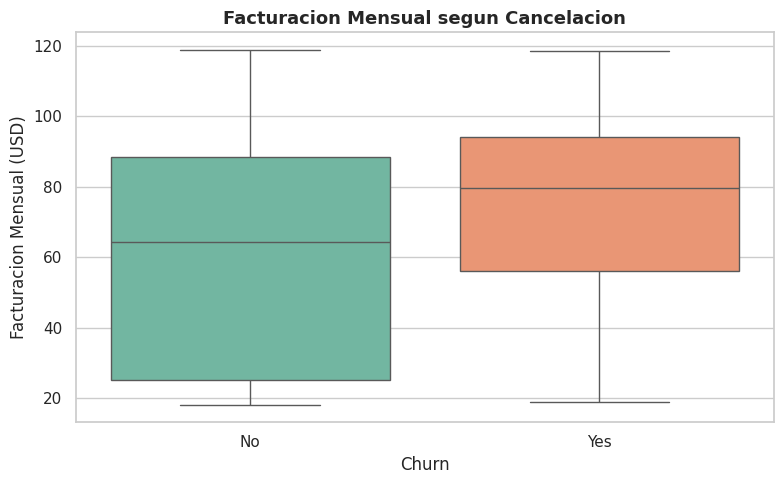

        count   mean    std    min    25%    50%   75%     max
Churn                                                         
No     5174.0  61.27  31.09  18.25  25.10  64.43  88.4  118.75
Yes    1869.0  74.44  24.67  18.85  56.15  79.65  94.2  118.35


In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='Charges_Monthly', data=df, palette='Set2')
plt.title('Facturacion Mensual segun Cancelacion', fontsize=13, fontweight='bold')
plt.xlabel('Churn')
plt.ylabel('Facturacion Mensual (USD)')
plt.tight_layout()
plt.show()

print(df.groupby('Churn')['Charges_Monthly'].describe().round(2))

### 4.4 Distribución de antigüedad (tenure)

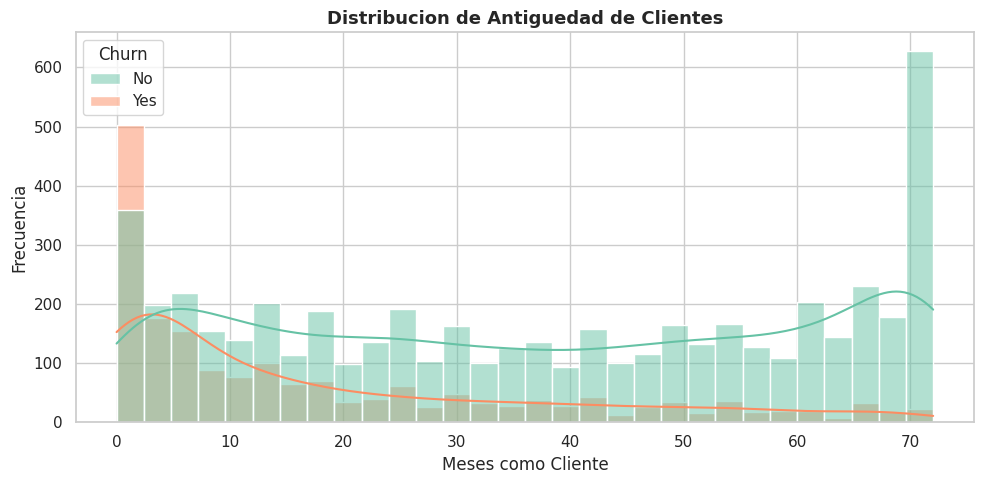

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True, palette='Set2')
plt.title('Distribucion de Antiguedad de Clientes', fontsize=13, fontweight='bold')
plt.xlabel('Meses como Cliente')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

### 4.5 Churn según grupo de antigüedad

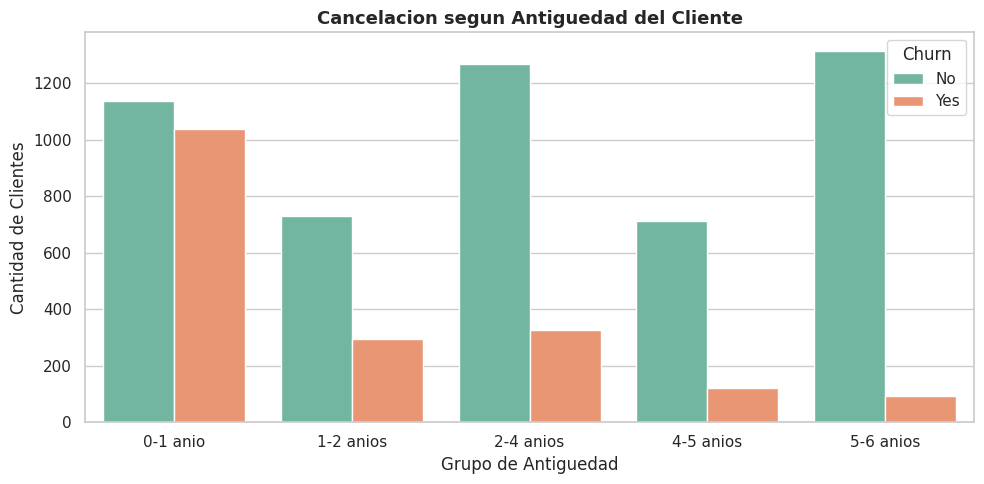

In [ ]:
df['Grupo_Tenure'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 60, 72],
    labels=['0-1 anio', '1-2 anios', '2-4 anios', '4-5 anios', '5-6 anios']
)

plt.figure(figsize=(10, 5))
sns.countplot(x='Grupo_Tenure', hue='Churn', data=df, palette='Set2')
plt.title('Cancelacion segun Antiguedad del Cliente', fontsize=13, fontweight='bold')
plt.xlabel('Grupo de Antiguedad')
plt.ylabel('Cantidad de Clientes')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

### 4.6 Churn según método de pago

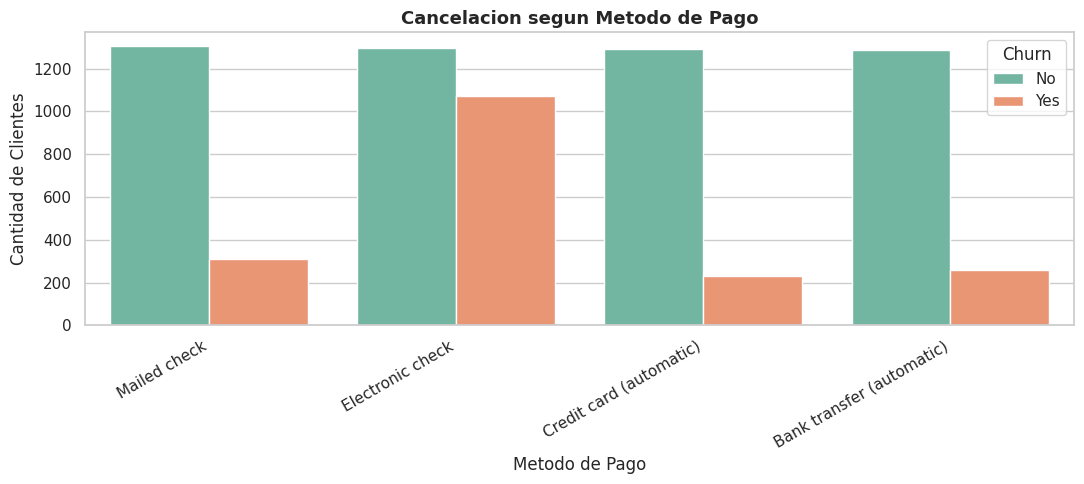

In [ ]:
plt.figure(figsize=(11, 5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df, palette='Set2')
plt.title('Cancelacion segun Metodo de Pago', fontsize=13, fontweight='bold')
plt.xlabel('Metodo de Pago')
plt.ylabel('Cantidad de Clientes')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

### 4.7 Mapa de correlación entre variables numéricas

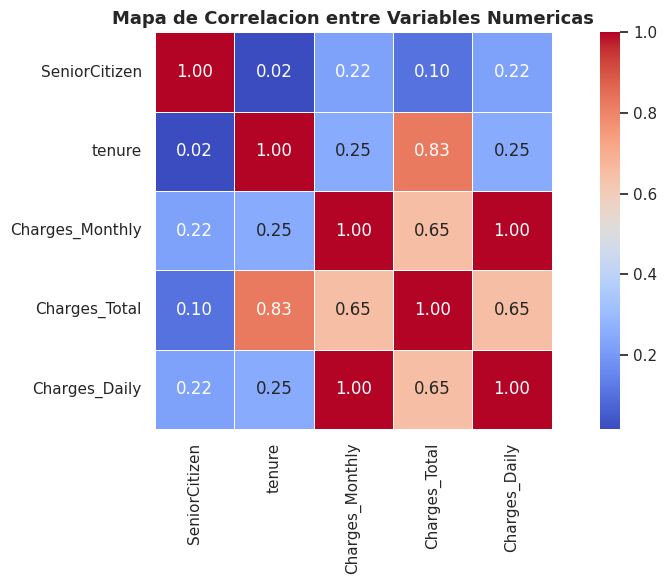

In [ ]:
plt.figure(figsize=(10, 6))
correlation = df.corr(numeric_only=True)
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Mapa de Correlacion entre Variables Numericas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📄 Informe Final

## 🔹 5. Conclusiones e Insights

A partir del análisis exploratorio se identificaron los siguientes hallazgos clave:

### Tasa de Churn
Aproximadamente el **26-27% de los clientes** cancelaron el servicio. Esta proporción representa un riesgo significativo para los ingresos de TelecomX.

### Tipo de Contrato
Los clientes con **contrato mensual (Month-to-month)** presentan la mayor tasa de cancelación. Los contratos de **uno o dos años** actúan como factor protector frente al Churn, generando un compromiso más duradero.

### Facturación Mensual
Los clientes que cancelaron tienden a tener **cargos mensuales más altos** (`Charges_Monthly`). Esto sugiere una posible percepción de bajo valor respecto al precio pagado.

### Antigüedad del Cliente
La mayor concentración de cancelaciones ocurre en los **primeros 12 meses**. Los clientes con más de 2 años de permanencia cancelan con mucha menor frecuencia, lo que señala que los primeros meses son críticos para la retención.

### Método de Pago
Los clientes que pagan mediante **cheque electrónico (Electronic check)** muestran una tasa de Churn notablemente más alta que quienes usan pagos automáticos.

### Correlaciones
Existe correlación positiva entre `tenure` y `Charges_Total`, y correlación negativa entre `tenure` y Churn, confirmando que la antigüedad es una variable protectora clave.

## 🔹 6. Recomendaciones Estratégicas

### 1. Incentivar contratos de mayor duración
Ofrecer descuentos o beneficios a clientes con contrato mensual para migrarlos a contratos anuales o bianuales, reduciendo la exposición al Churn.

### 2. Programa de fidelización en los primeros 12 meses
Implementar onboarding activo: seguimiento personalizado, beneficios de bienvenida y atención prioritaria durante el primer año, que es cuando el riesgo es más alto.

### 3. Migrar clientes a pagos automáticos
Incentivar el uso de débito automático o tarjeta en lugar del cheque electrónico, que está asociado a mayor tasa de Churn.

### 4. Revisar la propuesta de valor para clientes de alto costo
Analizar planes con mayor `Charges_Monthly` para asegurar que los clientes perciban valor adecuado por el precio pagado.

### 5. Modelo predictivo de Churn
Como siguiente paso, desarrollar un modelo de Machine Learning (regresión logística, Random Forest) para identificar en tiempo real qué clientes tienen mayor probabilidad de cancelar.